# Introducción al aprendizaje automatizado (O2026)
## Tutorial 9 - Regularización: Ridge, LASSO & Elastic Net 

**Objetivo:**  
Que se familiaricen con las técnicas de Regularización  

### Temario:
- Ejemplo de regresión para predecir salarios con la base de baseballistas (*hitters*)
- Regularización con penalidad L1 LASSO
- Regularización con penalidad L2 Ridge
- Regularización con penalidad L1 y L2 combinada en ElasticNet

### Modelos lineales regularizados con Ridge y Lasso

Exploraremos brevemente el conjunto de datos Baseballistas (["Hitters"](https://islp.readthedocs.io/en/latest/datasets/Hitters.html)) y usaremos la librería de sklearn para ajustar modelos lineales regularizados por Ridge y Lasso (son las siglas en inglés para: operador de selección y contracción mínima absoluta) con el fin de predecir el salario de los jugadores de béisbol.

Esta es una adaptación del Lab de Linear Models and Regularization Methods del libro "Introduction to Statistical Learning with Applications in Python" de Gareth James, Daniela Witten, Trevor Hastie, Robert Tibshirani y Jonathan Taylor. [Acá](https://islp.readthedocs.io/en/latest/labs/Ch06-varselect-lab.html) pueden encontrar más información

##### Baseball data, 'Hitters'
Datos de la Major League de Baseball Data en las temporadas 1986 y 1987.
La base de Hitters tiene las siguientes variables:
- AtBat: Number of times at bat in 1986
- Hits: Number of hits in 1986
- HmRun: Number of home runs in 1986
- Runs: Number of runs in 1986
- RBI: Number of runs batted in in 1986
- Walks: Number of walks in 1986
- Years: Number of years in the major leagues
- CAtBat: Number of times at bat during his career
- CHits: Number of hits during his career
- CHmRun: Number of home runs during his career
- CRuns: Number of runs during his career
- CRBI: Number of runs batted in during his career
- CWalks: Number of walks during his career
- League: A factor with levels A and N indicating player’s league at the end of 1986
- Division: A factor with levels E and W indicating player’s division at the end of 1986
- PutOuts: Number of put outs in 1986
- Assists: Number of assists in 1986
- Errors: Number of errors in 1986
- Salary: 1987 annual salary on opening day in thousands of dollars
- NewLeague: A factor with levels A and N indicating player’s league at the beginning of 1987


Nuestro objetivo será **predecir el salario** (regresión)

### 1. Leer el conjunto de datos y explorar la estructura de datos 

In [59]:
# Importamos los paquetes necesarios
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data

from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [60]:
Hitters = load_data('Hitters')
print(Hitters.info())
print('Dimensión de la base:', Hitters.shape, '\n')
#Vemos los missing values en Y
print('\nMissings en variable dependiente:', np.isnan(Hitters['Salary']).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

Dado que hay 59 observaciones sin el salario ($Y$ a predecir), eliminamos dichas filas sin variable dependiente.

In [61]:
Hitters = Hitters.dropna() 
print('\n Nueva dimensión de la base:', Hitters.shape)


 Nueva dimensión de la base: (263, 20)


In [4]:
Hitters

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [5]:
# que notan arriba en el index?
Hitters.reset_index(drop=True)# index original es descartado

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
1,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
2,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
3,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
4,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
259,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
260,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
261,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


### 2. Preparar las X e Y que usaremos en el modelo

Aquí seleccionamos las variables que utilizaremos en nuestro modelo y transformamos a dummies las que son strings

In [6]:
y = Hitters.Salary
y.shape

(263,)

Rapidamente, veamos la distribucion de salarios de los baseballistas

In [7]:
y.describe().round(2)

count     263.00
mean      535.93
std       451.12
min        67.50
25%       190.00
50%       425.00
75%       750.00
max      2460.00
Name: Salary, dtype: float64

In [8]:
print(Hitters.League.value_counts())
print(Hitters.Division.value_counts())
print(Hitters.NewLeague.value_counts())

# Creamos variables dummies para las variables string
dummies = pd.get_dummies(Hitters[['League', 'Division', 'NewLeague']], drop_first=True)
dummies

League
A    139
N    124
Name: count, dtype: int64
Division
W    134
E    129
Name: count, dtype: int64
NewLeague
A    141
N    122
Name: count, dtype: int64


,League_N,Division_W,NewLeague_N
1,True,True,True
2,False,True,False
3,True,False,True
4,True,False,True
5,False,True,False
...,...,...,...
317,True,False,True
318,False,False,False
319,False,True,False
320,False,False,False


In [9]:
#reseteamos el index (que notan arriba?)
dummies = dummies.reset_index(drop=True)

In [10]:
# Definimos las variables que incluiremos en el set de X

# Eliminamos salarios (porque es nuestra y) y las columnas de strings
X_num = Hitters.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')

X_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AtBat    263 non-null    float64
 1   Hits     263 non-null    float64
 2   HmRun    263 non-null    float64
 3   Runs     263 non-null    float64
 4   RBI      263 non-null    float64
 5   Walks    263 non-null    float64
 6   Years    263 non-null    float64
 7   CAtBat   263 non-null    float64
 8   CHits    263 non-null    float64
 9   CHmRun   263 non-null    float64
 10  CRuns    263 non-null    float64
 11  CRBI     263 non-null    float64
 12  CWalks   263 non-null    float64
 13  PutOuts  263 non-null    float64
 14  Assists  263 non-null    float64
 15  Errors   263 non-null    float64
dtypes: float64(16)
memory usage: 34.9 KB


In [11]:
X_num

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0
5,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497.0,127.0,7.0,65.0,48.0,37.0,5.0,2703.0,806.0,32.0,379.0,311.0,138.0,325.0,9.0,3.0
318,492.0,136.0,5.0,76.0,50.0,94.0,12.0,5511.0,1511.0,39.0,897.0,451.0,875.0,313.0,381.0,20.0
319,475.0,126.0,3.0,61.0,43.0,52.0,6.0,1700.0,433.0,7.0,217.0,93.0,146.0,37.0,113.0,7.0
320,573.0,144.0,9.0,85.0,60.0,78.0,8.0,3198.0,857.0,97.0,470.0,420.0,332.0,1314.0,131.0,12.0


In [12]:
X_num = X_num.reset_index(drop=True) # index original es descartado
X_num

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
0,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0
1,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0
2,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0
3,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0
4,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,497.0,127.0,7.0,65.0,48.0,37.0,5.0,2703.0,806.0,32.0,379.0,311.0,138.0,325.0,9.0,3.0
259,492.0,136.0,5.0,76.0,50.0,94.0,12.0,5511.0,1511.0,39.0,897.0,451.0,875.0,313.0,381.0,20.0
260,475.0,126.0,3.0,61.0,43.0,52.0,6.0,1700.0,433.0,7.0,217.0,93.0,146.0,37.0,113.0,7.0
261,573.0,144.0,9.0,85.0,60.0,78.0,8.0,3198.0,857.0,97.0,470.0,420.0,332.0,1314.0,131.0,12.0


**Pregunta:** Cuáles variables muestran alta correlacion lineal?

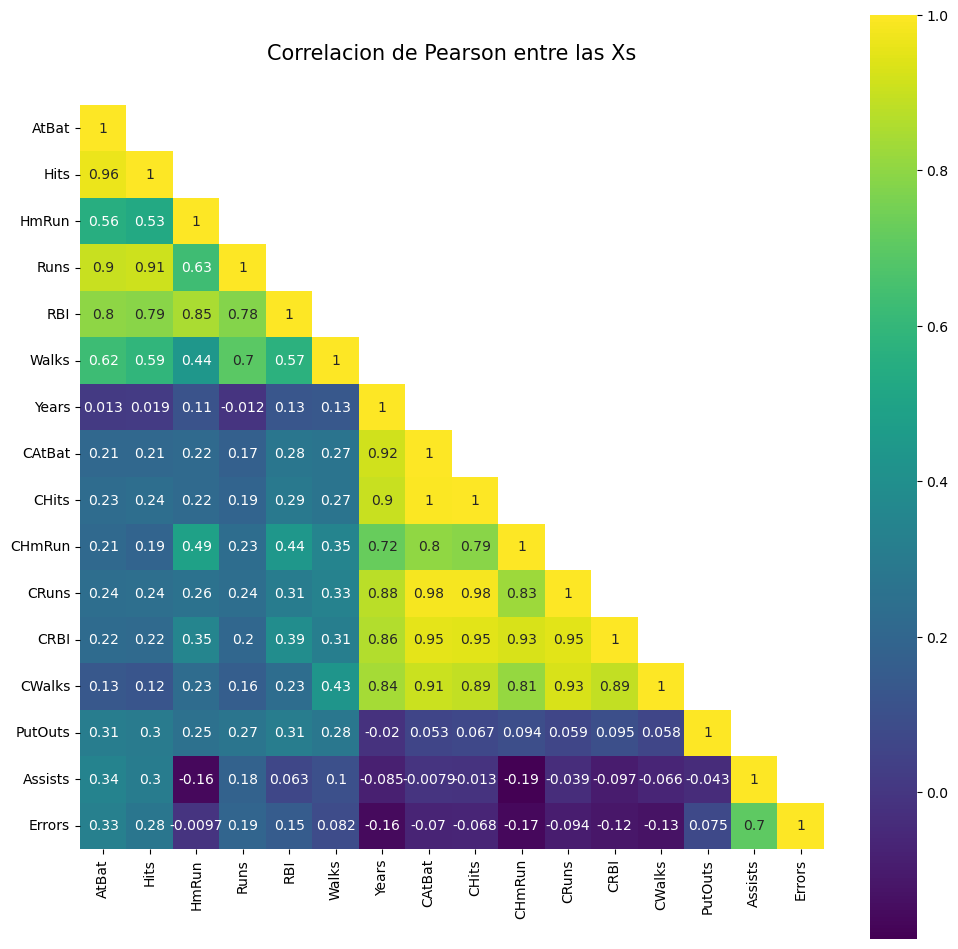

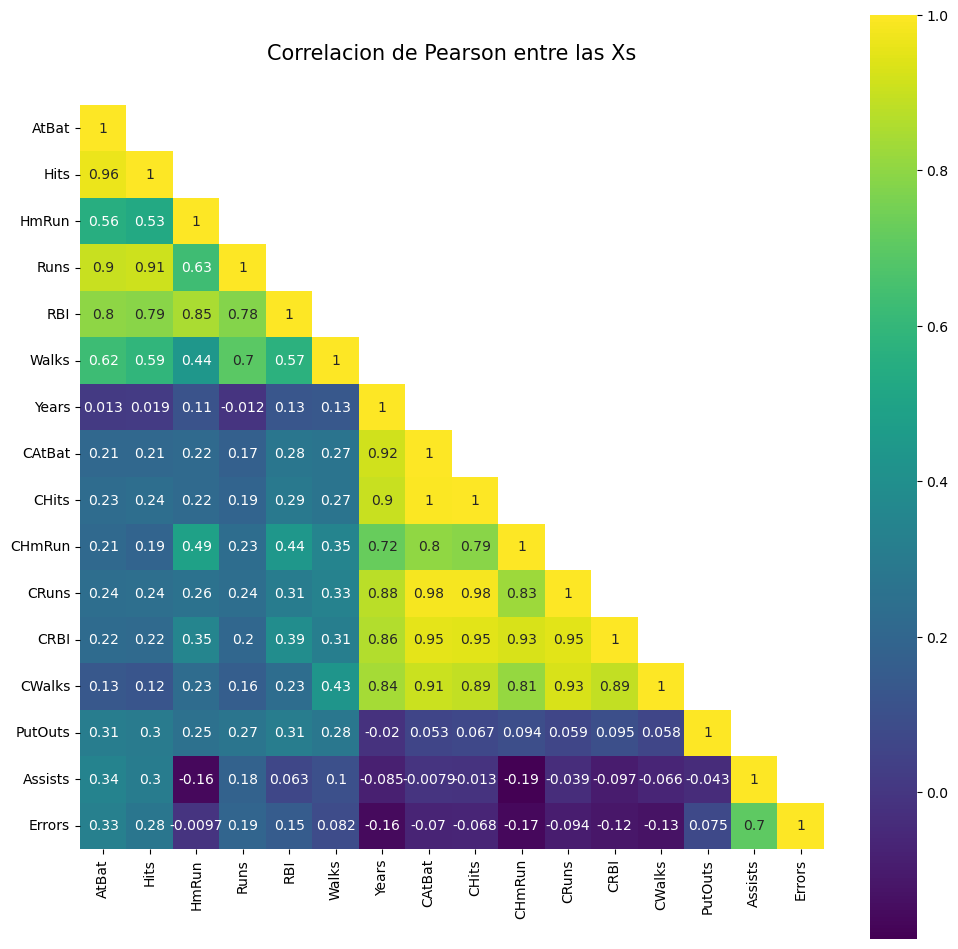

In [63]:
# Visualizamos la correlaciones dentro de la base de entrenamiento
colormap = plt.cm.viridis
fig = plt.figure(figsize=(12,12))
plt.title('Correlacion de Pearson entre las Xs', y=1.05, size=15)
mask = np.triu(np.ones_like(X_num.astype(float).corr(), dtype=bool), k=1)
sns.heatmap(X_num.astype(float).corr(), square=True, cmap=colormap, linecolor='white', annot=True, mask=mask)
fig.savefig("Hitters_corr_X_num.pdf",bbox_inches='tight')
plt.show()

#### Transformamos las variables numericas

In [14]:
# Iniciamos el Standard Scaler
sc = StandardScaler()

# Estandarizamos las observaciones de entrenamiento
X_transformed = pd.DataFrame(sc.fit_transform(X_num),index=X_num.index, columns=X_num.columns)


In [15]:
# Ahora sumamos las dummies como 1s y 0s
X = pd.concat([X_transformed, dummies[['League_N', 'Division_W', 'NewLeague_N']].astype(float)], axis=1)

In [16]:
# Chequeamos la matriz de predictores final que usaremos
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AtBat,263.0,0.00,1.0,-2.62,-0.82,0.06,0.83,1.93
Hits,263.0,0.00,1.0,-2.37,-0.81,-0.11,0.75,2.89
HmRun,263.0,0.00,1.0,-1.33,-0.76,-0.30,0.73,3.25
Runs,263.0,-0.00,1.0,-2.15,-0.83,-0.11,0.72,2.95
RBI,263.0,0.00,1.0,-1.99,-0.83,-0.17,0.76,2.69
Walks,263.0,0.00,1.0,-1.90,-0.84,-0.19,0.73,2.95
Years,263.0,-0.00,1.0,-1.32,-0.69,-0.27,0.56,3.49
CAtBat,263.0,0.00,1.0,-1.16,-0.80,-0.32,0.54,4.99
CHits,263.0,0.00,1.0,-1.11,-0.79,-0.32,0.51,5.46
CHmRun,263.0,0.00,1.0,-0.84,-0.66,-0.36,0.28,5.84


In [17]:
# chequeamos que esten bien los porcentajes de arriba
print(Hitters.League.value_counts(normalize=True).round(2))
print(Hitters.Division.value_counts(normalize=True).round(2))
print(Hitters.NewLeague.value_counts(normalize=True).round(2))

League
A    0.53
N    0.47
Name: proportion, dtype: float64
Division
W    0.51
E    0.49
Name: proportion, dtype: float64
NewLeague
A    0.54
N    0.46
Name: proportion, dtype: float64


In [18]:
X

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
0,-0.602900,-0.595675,-0.528551,-1.206112,-0.522063,-0.097527,1.397893,0.346791,0.174373,-0.002920,-0.121671,0.258966,0.435334,1.221499,-0.523191,0.213352,1.0,1.0,1.0
1,0.512542,0.492260,0.729966,0.441515,0.794060,1.609373,-0.901200,-0.452865,-0.409892,-0.076054,-0.415105,-0.199590,0.010373,2.109109,-0.253863,0.819964,0.0,1.0,0.0
2,0.628167,0.736490,0.958788,0.402286,1.026317,-0.189792,0.770868,1.301558,1.318174,1.898565,1.412051,1.572666,0.355654,-0.324661,-0.744179,-0.848219,1.0,0.0,1.0
3,-0.562092,-0.462459,-0.185319,-0.617673,-0.367225,-0.512719,-1.110209,-0.990935,-0.960153,-0.697693,-0.947521,-0.881228,-0.862315,1.840678,-0.543909,-0.696566,1.0,0.0,1.0
4,1.294712,1.358167,-0.871783,0.755349,-0.018840,-0.282057,0.770868,0.766993,0.634985,-0.612370,0.422846,0.017294,-0.251434,-0.031177,2.087225,2.488147,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,0.634968,0.425651,-0.528551,0.402286,-0.134968,-0.189792,-0.483183,0.019917,0.129549,-0.453913,0.053785,-0.060165,-0.463914,0.122723,-0.757991,-0.848219,1.0,0.0,1.0
259,0.600961,0.625476,-0.757373,0.833807,-0.057549,2.439756,0.979876,1.250292,1.219250,-0.368590,1.620783,0.373605,2.332483,0.079774,1.810990,1.729882,0.0,0.0,0.0
260,0.485336,0.403449,-0.986194,0.245369,-0.328515,0.502194,-0.274175,-0.419565,-0.446988,-0.758638,-0.436281,-0.735605,-0.433560,-0.908051,-0.039781,-0.241607,0.0,1.0,0.0
261,1.151881,0.803098,-0.299730,1.186870,0.329546,1.701637,0.143842,0.236810,0.208378,0.338372,0.329068,0.277556,0.272180,3.662427,0.084525,0.516658,0.0,0.0,0.0


In [24]:
# Visualizamos la correlaciones dentro de la base de entrenamiento
colormap = plt.cm.viridis
plt.figure(figsize=(12,12))
plt.title('Correlacion de Pearson entre las Xs', y=1.05, size=15)
sns.heatmap(X_train.astype(float).corr(),
            square=True, 
            cmap=colormap, 
            linecolor='white', 
            annot=True)


<Axes: title={'center': 'Correlacion de Pearson entre las Xs'}>

### 3. Dividimos la base en observaciones para entrenamiento y testeo

Ahora dividimos la muestra en un conjunto de entrenamiento y un conjunto de prueba para luego estimar el error en el conjunto de prueba. 

In [64]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# Revisamos cuantas observaciones quedaron para Test y cuantas para Entrenamiento.
print(f'El conjunto de entrenamiento tiene {len(X_train)} observaciones.')
print(f'El conjunto de test tiene {len(X_test)} observaciones.')

El conjunto de entrenamiento tiene 184 observaciones.
El conjunto de test tiene 79 observaciones.


### 4. Regularización


Les dejo la documentación para que puedan comparar:
- Para **clasificación** ($Y$ categorica) recuerden que usamos la función [LogisticRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Con dicha función, se puede hacer un ejercicio de clasificacion con amabas penalidades. Lasso usa una penalidad llamada l1 (que fuerza algunos coeficientes para que sean iguales a 0, seleccionando variables) y Ridge usa una penalidad llamada l2 (que hace que algunos coeficientes sean más cercanos a 0 pero sin llegar a 0)
- Para **regresión** ($Y$ numerica)  usaremos la funciones [Ridge()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge) y [Lasso()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso) 


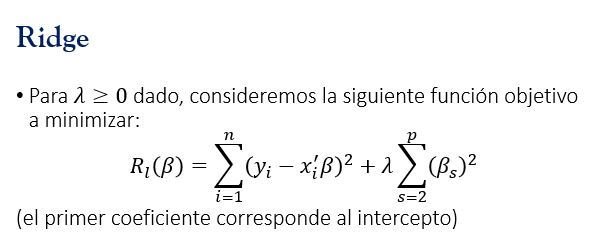

Usamos la funciones [Ridge()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) y [Lasso()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) para realizar distintas regresiones lineales regularizadas. Estas funciones tienen un argumento  **alfa** $\alpha$ (es el **λ** pero con otro nombre) que **controla el peso de la regularización**.

## 5. Regresión con Ridge (L2 norm)

Empecemos con un modelo sin penalidad (*shrinkage*), formalmente $\alpha =0$:

In [65]:
alpha = 0
print("Alpha:", alpha)

ridge_a0 = Ridge(alpha = alpha)
ridge_a0.fit(X_train, y_train)             
pred_a0 = ridge_a0.predict(X_test) # notar prediccion de Y sombrerito con base de testeo
mse_a0 = mean_squared_error(y_test, pred_a0)

print("Mean Squared Error de testeo (MSE test): ", mse_a0)   
print("Coeficientes del modelo:")
print(pd.Series(ridge_a0.coef_, index = X_train.columns)) 

Alpha: 0
Mean Squared Error de testeo (MSE test):  123843.29730614166
Coeficientes del modelo:
AtBat         -379.933191
Hits           429.117974
HmRun           45.119268
Runs           -54.818746
RBI            -93.959120
Walks          150.231240
Years            7.423621
CAtBat        -658.397424
CHits          375.641952
CHmRun          83.247773
CRuns          424.186758
CRBI           206.994963
CWalks        -225.852438
PutOuts         77.205678
Assists         63.235295
Errors         -18.877526
League_N         8.794443
Division_W     -92.645620
NewLeague_N    -59.523532
dtype: float64


El $MSE_{test}$ con $\alpha=0$ es: 123,843.3 

Probemos elegir arbitrariamente el alpha usando $\alpha=1$:

In [67]:
alpha = 1
print("Alpha:", alpha)

ridge_a1 = Ridge(alpha = alpha)
ridge_a1.fit(X_train, y_train)             
pred_a1 = ridge_a1.predict(X_test)
mse_a1 = mean_squared_error(y_test, pred_a1)

print("Mean Squared Error de testeo (MSE test): ", mse_a1)   
print("Coeficientes del modelo:")
print(pd.Series(ridge_a1.coef_, index = X_train.columns)) 

Alpha: 1
Mean Squared Error de testeo (MSE test):  117222.17983455039
Coeficientes del modelo:
AtBat         -350.560119
Hits           377.036016
HmRun           25.128853
Runs           -21.663838
RBI            -69.867147
Walks          135.118911
Years          -44.386405
CAtBat        -249.562189
CHits          175.178454
CHmRun          86.366250
CRuns          280.400083
CRBI           158.233238
CWalks        -198.013668
PutOuts         76.460039
Assists         52.718109
Errors         -22.039565
League_N         4.323832
Division_W    -102.819379
NewLeague_N    -56.183781
dtype: float64


El $MSE_{test}$ con $\alpha = 1$ es 117,196.67

Ahora probemos que pasa con un alpha muy grande, por ej. $\alpha=10^{10}$:

In [68]:
alpha = 10**10
print("Alpha:", alpha)

ridge_a10b = Ridge(alpha)
ridge_a10b.fit(X_train, y_train)             
pred_a10b = ridge_a10b.predict(X_test)  
mse_a10b = mean_squared_error(y_test, pred_a10b)

print("Mean Squared Error de testeo (MSE test): ",mse_a10b)   
print("Coeficientes del modelo:")
print(pd.Series(ridge_a10b.coef_, index = X_train.columns)) 

Alpha: 10000000000
Mean Squared Error de testeo (MSE test):  238884.05591734318
Coeficientes del modelo:
AtBat          3.009434e-06
Hits           3.431606e-06
HmRun          2.616096e-06
Runs           3.242998e-06
RBI            3.173408e-06
Walks          3.055631e-06
Years          3.133698e-06
CAtBat         4.086980e-06
CHits          4.299573e-06
CHmRun         3.766173e-06
CRuns          4.373997e-06
CRBI           4.221870e-06
CWalks         3.638914e-06
PutOuts        2.119939e-06
Assists        4.575909e-07
Errors         7.090925e-09
League_N      -5.029579e-07
Division_W    -7.420999e-07
NewLeague_N   -4.381361e-07
dtype: float64


El $MSE_{test}$ con $\alpha=10^{10}$ es 238,884.06

Esta gran penalización reduce los coeficientes en un grado muy grande, esencialmente reduciéndose a un modelo que contiene solo el intercepto. Esta contracción excesiva hace que el modelo sea demasiado sesgado, lo que resulta en un $MSE_{test}$ más alto.

#### Plot Ridge: coeficientes según parámetros de ajuste alfa

Generaremos una matriz de valores alfa que van desde muy grandes a muy pequeños, esencialmente cubriendo la gama completa de escenarios desde el modelo nulo que contiene solo la intersección, hasta el ajuste de mínimos cuadrados.

Ahora veamos la relación entre alfa y los coeficientes, una línea para cada característica.

In [33]:
# Matriz de valores de alfa
alphas = 10**np.linspace(6,-2,50)*0.5
np.set_printoptions(suppress = True)
alphas

array([500000.        , 343324.42250215, 235743.31817287, 161872.87714088,
       111149.82412631,  76320.89835876,  52405.65670773,  35984.28365006,
        24708.56680662,  16966.10885948,  11649.75905258,   7999.29359803,
         5492.70570994,   3771.56003168,   2589.73733962,   1778.24015311,
         1221.02654727,    838.41646841,    575.69769966,    395.30216055,
          271.43377197,    186.37968602,    127.97739613,     87.87553124,
           60.33963203,     41.43213864,     28.44933015,     19.53469969,
           13.41347898,      9.21034985,      6.32427608,      4.34255687,
            2.98181166,      2.04745753,      1.40588435,      0.96534886,
            0.66285568,      0.45514909,      0.3125276 ,      0.21459671,
            0.14735259,      0.10117948,      0.06947477,      0.04770477,
            0.03275643,      0.02249216,      0.01544422,      0.01060475,
            0.00728174,      0.005     ])

In [69]:
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)

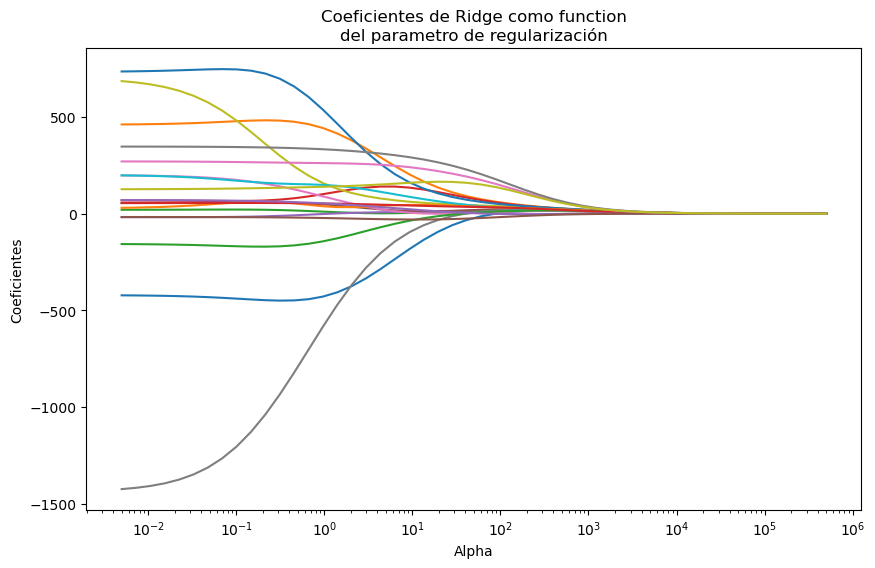

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coeficientes")
plt.title("Coeficientes de Ridge como function" "\ndel parametro de regularización")
plt.axis("tight")
plt.show()

En el lado izquierdo casi no hay penalización, por lo que se pueden observar todos los valores que toman los coeficientes de las disttintas variables. En el lado derecho podemos ver un modelo con coeficientes muy cercanos a cero. Esto se debe a una penalización muy alta. 

Entonces ajustar un modelo de regresión de Ridge con $\alpha = 1$ conduce a un $MSE_{test}$  de prueba más bajo que ajustar un modelo con solo una intersección. 

#### Comparamos con un modelo lineal (sin regularizar)

Ahora verificamos si existe algún beneficio al realizar la regresión de Ridge con $\alpha = 1$ en lugar de simplemente realizar la regresión por mínimos cuadrados. 

In [71]:
from sklearn.linear_model import LinearRegression
modelo_lineal = LinearRegression().fit(X_train, y_train)
pred_lin = modelo_lineal.predict(X_test)
mse_lin = mean_squared_error(y_test, pred_lin)

print("Mean Squared Error de testeo (MSE test): ", mse_lin) 
print("Coeficientes de la regresión lineal:")
print(pd.Series(modelo_lineal.coef_, index = X_train.columns)) 

Mean Squared Error de testeo (MSE test):  123843.29730614129
Coeficientes de la regresión lineal:
AtBat         -379.933191
Hits           429.117974
HmRun           45.119268
Runs           -54.818746
RBI            -93.959120
Walks          150.231240
Years            7.423621
CAtBat        -658.397424
CHits          375.641952
CHmRun          83.247773
CRuns          424.186758
CRBI           206.994963
CWalks        -225.852438
PutOuts         77.205678
Assists         63.235295
Errors         -18.877526
League_N         8.794443
Division_W     -92.645620
NewLeague_N    -59.523532
dtype: float64


El modelo con Ridge es mejor que el de mínimos cuadrados ordinarios al comparar los $MSE_{test}$. 
Como era de esperar, ninguno de los coeficientes es exactamente cero. Recordar: la regresión de Ridge no realiza  selección de variables!

Ahora, en lugar de elegir arbitrariamente alpha $ = 1 $, sería mejor usar la validación cruzada para elegir el parámetro de ajuste alpha. 

#### Ridge con validación cruzada 

Realizamos una validación cruzada con k=5 para elegir el mejor alfa, reajustar el modo, calcular el error de prueba asociado e imprimir los mejores coeficientes de modelos. Esta vez regularizando con [RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html)

In [41]:
ridgecv = RidgeCV(alphas=alphas, cv=5).fit(X_train, y_train)
print("El mejor alpha:", ridgecv.alpha_.round(2))

# Ahora con el alpha óptimo, volvemos a estimar nuestro modelo
ridge = Ridge(alpha=ridgecv.alpha_)
ridge = ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
mse_ridge_cv = mean_squared_error(y_test, ridge_pred)

print("Mean Squared Error de testeo (MSE test):", mse_ridge_cv)   

print("Coeficientes del mejor modelo:")
print(pd.Series(ridgecv.coef_, index = X_train.columns)) 


El mejor alpha: 1.41
Mean Squared Error de testeo (MSE test): 115974.7638038888
Coeficientes del mejor modelo:
AtBat         -331.257822
Hits           353.427831
HmRun           19.805710
Runs           -12.222031
RBI            -63.990076
Walks          128.869848
Years          -51.271281
CAtBat        -198.716249
CHits          162.723823
CHmRun          87.013128
CRuns          245.659974
CRBI           148.705596
CWalks        -185.835446
PutOuts         76.031405
Assists         50.206612
Errors         -22.819852
League_N         4.191882
Division_W    -104.283342
NewLeague_N    -55.161473
dtype: float64


## 6. Regularización con LASSO (L1 norm)

Iniciemos, nuevamente con un modelo sin shrinkage $\alpha=0$:

In [43]:
alpha = 0
print("Alpha:", alpha)

lasso_a0 = Lasso(alpha = alpha)
lasso_a0.fit(X_train, y_train)             
pred_a0_l = lasso_a0.predict(X_test)
mse_a0_l = mean_squared_error(y_test, pred_a0_l)

print("Mean Squared Error de testeo (MSE test):", mse_a0_l)   
print("Coeficientes del modelo para LASSO:")
print(pd.Series(lasso_a0.coef_, index = X_train.columns))

Alpha: 0
Mean Squared Error de testeo (MSE test): 124167.14691968991
Coeficientes del modelo para LASSO:
AtBat         -375.869838
Hits           424.109839
HmRun           44.114594
Runs           -52.721706
RBI            -93.535816
Walks          149.092136
Years           10.561312
CAtBat        -691.576221
CHits          415.666545
CHmRun          90.943565
CRuns          414.857571
CRBI           197.044593
CWalks        -222.426285
PutOuts         77.039979
Assists         63.569561
Errors         -18.810783
League_N         9.600753
Division_W     -92.064249
NewLeague_N    -60.040486
dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.843e+06, tolerance: 3.450e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordi

El $MSE_{test}$  con $\alpha=0$ es: 124,167.15

Seguimos con un $\alpha=1$

In [73]:
alpha = 1
print("Alpha:", alpha)

lasso_a1 = Lasso(alpha = alpha)
lasso_a1.fit(X_train, y_train)             
pred_a1_l = lasso_a1.predict(X_test)
mse_a1_l = mean_squared_error(y_test, pred_a1_l)

print("Mean Squared Error de testeo (MSE test):", mse_a1_l)   
print("Coeficientes del modelo para LASSO:")
print(pd.Series(lasso_a1.coef_, index = X_train.columns)) 

Alpha: 1
Mean Squared Error de testeo (MSE test): 117942.92923599479
Coeficientes del modelo para LASSO:
AtBat         -382.904437
Hits           408.814228
HmRun           20.280848
Runs           -26.773909
RBI            -61.136111
Walks          136.495003
Years          -25.755954
CAtBat        -302.355988
CHits          113.375988
CHmRun          68.056256
CRuns          374.341940
CRBI           191.918547
CWalks        -212.369189
PutOuts         77.189764
Assists         52.458564
Errors         -17.659395
League_N        -0.000000
Division_W     -94.160643
NewLeague_N    -46.586132
dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.139e+04, tolerance: 3.450e+03
  model = cd_fast.enet_coordinate_descent(


El  $MSE_{test}$  con $\alpha=1$ es 117,042.9 y notamos que el coeficientes de `League_N` es $0$ (con `test_size=0.3`) 

##### Para la casa: 
Probar con $\alpha=10^{10}$

#### Plot Lasso: coeficientes según parámetros de ajuste alfa

Hagamos lo mismo que hicimos para Ridge y grafiquemos la evolución de los parámetros en función de alpha.


In [46]:
# Matriz de valores de alfa
alphas = 10**np.linspace(6,-2,50)*0.5
np.set_printoptions(suppress = True)
alphas

array([500000.        , 343324.42250215, 235743.31817287, 161872.87714088,
       111149.82412631,  76320.89835876,  52405.65670773,  35984.28365006,
        24708.56680662,  16966.10885948,  11649.75905258,   7999.29359803,
         5492.70570994,   3771.56003168,   2589.73733962,   1778.24015311,
         1221.02654727,    838.41646841,    575.69769966,    395.30216055,
          271.43377197,    186.37968602,    127.97739613,     87.87553124,
           60.33963203,     41.43213864,     28.44933015,     19.53469969,
           13.41347898,      9.21034985,      6.32427608,      4.34255687,
            2.98181166,      2.04745753,      1.40588435,      0.96534886,
            0.66285568,      0.45514909,      0.3125276 ,      0.21459671,
            0.14735259,      0.10117948,      0.06947477,      0.04770477,
            0.03275643,      0.02249216,      0.01544422,      0.01060475,
            0.00728174,      0.005     ])

In [47]:
coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, fit_intercept=False, max_iter=100000)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

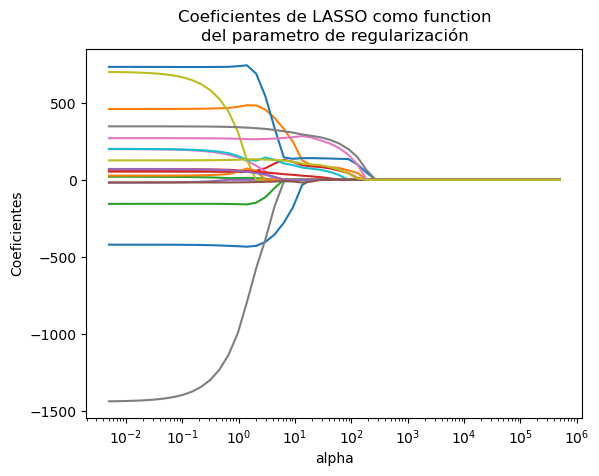

In [49]:
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coeficientes")
plt.title("Coeficientes de LASSO como function" "\ndel parametro de regularización")
plt.axis("tight")
plt.show()

##### Cantidad de coeficientes que LASSO lleva a 0

Podemos visualizar cuantos coeficienes se hacen exactamente igual a 0 para cada valor de penalización

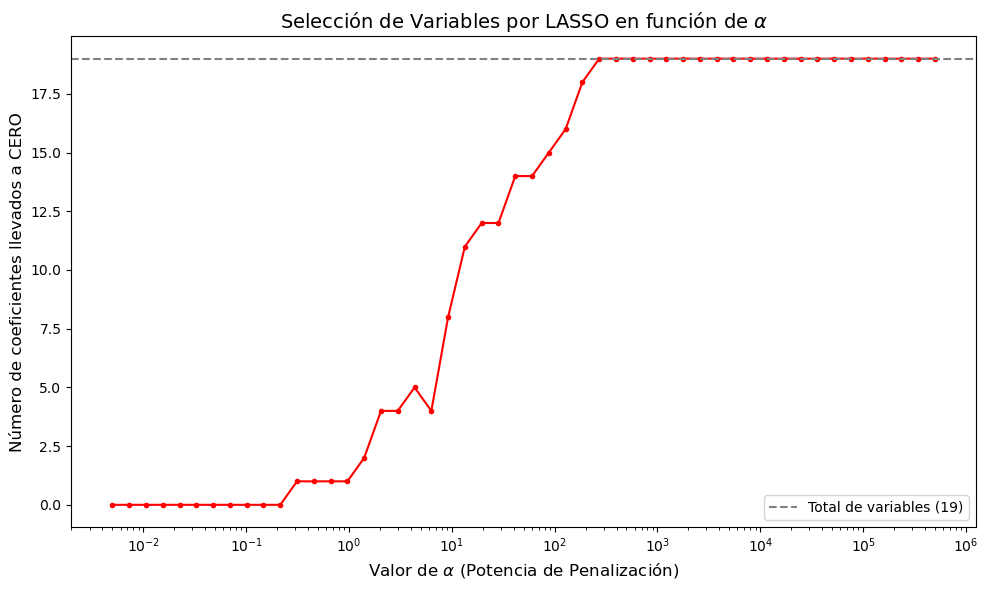

In [50]:
# 1. Inicializar listas para almacenar los resultados
alphas_list = []
num_coef_cero = []

# 2. Iterar sobre la grilla de alphas y ajustar el modelo LASSO
for alpha in alphas:
    # 2a. Ajustar el modelo LASSO
    # Usamos max_iter más grande si el modelo tiene problemas para converger
    lasso = Lasso(alpha=alpha, max_iter=10000, tol=0.01)
    lasso.fit(X_train, y_train)

    # 2b. Contar los coeficientes que son CERO (o muy cercanos a cero)
    # LASSO hace que los coeficientes sean *exactamente* cero.
    # np.isclose se usa para manejar posibles errores de precisión flotante.
    # Sumamos True (1) y False (0) para obtener el conteo.
    count = np.sum(np.isclose(lasso.coef_, 0, atol=1e-8)) # atol es la tolerancia
    
    # 2c. Almacenar resultados
    alphas_list.append(alpha)
    num_coef_cero.append(count)

# 3. Preparar los datos para el gráfico
# Calcular el número total de variables para la línea de referencia
num_variables_total = X_train.shape[1]

# 4. Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(alphas_list, num_coef_cero, marker='o', linestyle='-', color='red', markersize=3)

# 4a. Añadir línea de referencia para el total de variables
plt.axhline(y=num_variables_total, color='grey', linestyle='--', label=f'Total de variables ({num_variables_total})')

# 4b. Configuración del eje X en escala logarítmica (es estándar para alfa)
plt.xscale('log')
plt.xlabel(r'Valor de $\alpha$ (Potencia de Penalización)', fontsize=12)
plt.ylabel('Número de coeficientes llevados a CERO', fontsize=12)
plt.title('Selección de Variables por LASSO en función de $\\alpha$', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

#### Lasso con validación cruzada 
Realizamos una validación cruzada de 5 veces para elegir el mejor alfa, reajustar el modelo, calcular el error de prueba asociado e imprimir los mejores coeficientes de modelos.

In [75]:
# Usamos cross-validation para dividir la muestra en training y validation sets
lassocv = LassoCV(alphas=alphas, cv=5, max_iter=100000, random_state=100)
lassocv.fit(X_train, y_train)
print("Alpha óptimo:", lassocv.alpha_.round(2))

# Ahora estimamos nuevamente el modelo con el alpha (lambda) óptimo
lasso = Lasso(alpha=lassocv.alpha_)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
mse_cv_l = mean_squared_error(y_test, lasso_pred)

print("Mean Squared Error de testeo (MSE test):", mse_cv_l)
print("Coeficientes del mejor modelo:")
pd.Series(lasso.coef_, index=X_train.columns)



Alpha óptimo: 2.98
Mean Squared Error de testeo (MSE test): 112091.67460334329
Coeficientes del mejor modelo:


AtBat         -334.549006
Hits           349.048469
HmRun           -0.000000
Runs            -0.000000
RBI            -24.353737
Walks          110.674104
Years          -54.232114
CAtBat          -0.000000
CHits            0.000000
CHmRun          74.705174
CRuns          221.580272
CRBI           116.551573
CWalks        -153.890131
PutOuts         71.965537
Assists         35.724728
Errors         -15.320810
League_N        -0.000000
Division_W     -93.680601
NewLeague_N    -35.590573
dtype: float64

## 7. Perfomance final y comparacion de coeficientes
Comparamos el modelo lineal, con la regularizacion por lasso y ridge usando la penalidad optima en cada caso.

In [76]:
print("Mean Squared Error de testeo (MSE test) con MCO: ", mse_lin)
print("Mean Squared Error de testeo (MSE test) con Ridge: ", mse_ridge_cv)
print("Mean Squared Error de testeo (MSE test) con Lasso: ", mse_cv_l)

Mean Squared Error de testeo (MSE test) con MCO:  123843.29730614129
Mean Squared Error de testeo (MSE test) con Ridge:  115974.7638038888
Mean Squared Error de testeo (MSE test) con Lasso:  112091.67460334329


Exportamos los coeficiente en una tabla y comparamos el modelo lineal con Ridge

In [77]:
# 1. Extraer los coeficientes de ambos modelos
# Los coeficientes de un modelo scikit-learn se encuentran en el atributo .coef_
coefs_lineal = modelo_lineal.coef_
coefs_ridge_cv = ridge.coef_
coefs_lasso_cv= lasso.coef_


# 2. Obtener los nombres de las variables (columnas)
nombres_variables = X_train.columns

# 3. Crear el DataFrame de coeficientes
df_coeficientes = pd.DataFrame({
    'Variable': nombres_variables,
    'Lineal_OLS': coefs_lineal,
    'Ridge_aplha_cv': coefs_ridge_cv,  
    'LASSO_aplha_cv': coefs_lasso_cv  
})

# 4. Agregar el intercepto
# El intercepto (.intercept_) debe agregarse por separado ya que no está en el array .coef_
intercepto_df = pd.DataFrame({
    'Variable': ['(Intercepto)'],
    'Lineal_OLS': [modelo_lineal.intercept_],
    'Ridge_aplha_cv': [ridge.intercept_],
    'LASSO_aplha_cv': [lasso.intercept_]
})

# 5. Crear el DataFrame con los valores de MSE
mse_df = pd.DataFrame({
    'Variable': ['MSE'],
    'Lineal_OLS': [mse_lin],
    'Ridge_aplha_cv': [mse_ridge_cv],
    'LASSO_aplha_cv': [mse_cv_l]
})


# 6. Combinar los coeficientes de las variables y el intercepto
df_comp = pd.concat([df_coeficientes, intercepto_df, mse_df], ignore_index=True).round(2)

df_comp

,Variable,Lineal_OLS,Ridge_aplha_cv,LASSO_aplha_cv
0,AtBat,-379.93,-422.11,-334.55
1,Hits,429.12,460.98,349.05
2,HmRun,45.12,20.09,-0.00
3,Runs,-54.82,68.32,-0.00
4,RBI,-93.96,-18.37,-24.35
5,Walks,150.23,54.97,110.67
6,Years,7.42,197.72,-54.23
7,CAtBat,-658.40,-1423.74,-0.00
8,CHits,375.64,685.24,0.00
9,CHmRun,83.25,197.95,74.71


Qué variables quedan afuera del modelo segun LASSO?

In [78]:
# 1. Definir una tolerancia pequeña para considerar un coeficiente como cero
# Esto es importante debido a la precisión de punto flotante.
TOLERANCIA = 0

# 2. Crear una máscara booleana: True donde el coeficiente de LASSO es (casi) cero
# np.isclose(array, valor, atol=tolerancia) es la forma recomendada en NumPy
mascara_cero = np.isclose(coefs_lasso_cv, 0, atol=TOLERANCIA)

# 3. Aplicar la máscara a los nombres de las variables
# Usamos el array de nombres de columnas (nombres_variables) para seleccionar solo
# aquellas que tienen True en la máscara (coeficiente cero).
variables_cero = nombres_variables[mascara_cero]

# 4. Convertir a lista y mostrar el resultado
lista_variables_cero = variables_cero.tolist()

print("Variables cuyos coeficientes LASSO son CERO:")
print(lista_variables_cero)

Variables cuyos coeficientes LASSO son CERO:
['HmRun', 'Runs', 'CAtBat', 'CHits', 'League_N']


#### Resumen
Con alpha elegido por validación cruzada, el $MSE_{test}$ del modelo Lasso es un poco mejor que el de regresión de Ridge. 

A su vez, Lasso tiene una gran ventaja sobre la regresión de Ridge, ya que produce modelos más simples e interpretables que involucran solo a un subconjunto de predictores.

## 8. Elastic Net

Con la funcion [ElasticNet()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) hay que tener encuenta que controlar se *"reparte"* peso tanto a la penalidad de LASSO como de Ridge. La formula que la función tiene en cuenta es:

$1 / (2 \times n samples) * ||y - Xw||^2_2 + \alpha  l1_{ratio}  ||w||_1 + 0.5  \alpha  (1 - l1_{ratio}) ||w||^2_2$

Por lo tanto, con $\alpha=1$ reparte $0.5$ como peso a ambas penalidades. En otras palabras, la penalidad de LASSO y Ridge tienen igual peso en la función

In [58]:
alpha = 1
print("Alpha:", alpha)

elnet_a1 = ElasticNet(alpha = alpha)
elnet_a1.fit(X_train, y_train)             
pred_a1 = elnet_a1.predict(X_test)
mse_a1 = mean_squared_error(y_test, pred_a1)

print("Mean Squared Error de testeo (MSE test) con ElasticNet: ", mse_a1)   
print("Coeficientes del modelo:")
print(pd.Series(elnet_a1.coef_, index = X_train.columns)) 

Alpha: 1
Mean Squared Error de testeo (MSE test) con ElasticNet:  117196.33567576308
Coeficientes del modelo:
AtBat           0.000000
Hits           48.510295
HmRun           0.000000
Runs           29.435540
RBI             9.930813
Walks          33.557087
Years          -1.846423
CAtBat         23.530738
CHits          42.068669
CHmRun         36.020880
CRuns          41.356482
CRBI           43.363376
CWalks          6.657616
PutOuts        44.365060
Assists         8.171584
Errors        -12.936909
League_N       -1.705246
Division_W    -39.042851
NewLeague_N    -8.433577
dtype: float64


#### Elastic Net con validación cruzada
En este caso, la ponderación clave en la funcion de [ElasticNetCV()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNetCV.html) es `l1_ratio`. Es decir, cuánto peso le samos a la penalidad de LASSO vs. Ridge y puede tomar valores entre $0$ y $1$.

In [ ]:
# Grilla de l1_ratio
l1_ratios = [.1, .5, .7, .9, .95, .99, 1]

# Usamos cross-validation para dividir la muestra en training y validation sets
elnetcv = ElasticNetCV(l1_ratio=l1_ratios, cv=5, max_iter=100000, random_state=100)
elnetcv.fit(X_train, y_train)
print("Ratio de penalidades óptima:", elnetcv.l1_ratio_)

Este ratio de casi 1 le da mas peso a la penalizacion L1 de LASSO y por eso nos selecciona predictores.

In [ ]:
# Ahora estimamos nuevamente el modelo con el ratio óptimo
elnet = ElasticNet(alpha=elnetcv.l1_ratio_)
elnet.fit(X_train, y_train)
elnet_pred = elnet.predict(X_test)
mse_elnet_cv = mean_squared_error(y_test, elnet_pred)

print("Mean Squared Error de testeo (MSE test) con ElasticNet por CV", mse_elnet_cv.round(2))
print("Coeficientes del mejor modelo:")
print(pd.Series(elnet.coef_, index=X_train.columns).round(2))

##### Tarea para la casa
Exportar los coeficientes del modelo lineal y los tres modelos de regularización con su $MSE_{test}$ luego de elegir la penalidad optima por CV y comparar